# Team 5 — DEM Project Milestone 4
## Delhi Air Quality: SQLite Database Load + ML Pollution Forecasting

**Dataset**: Delhi Air Quality · 8.8M rows · 15 stations · 13 pollutants · 2024  
**Targets**: Next-day concentration forecasting for all 13 pollutants  
**Models**: Random Forest · Ridge Regression  

---

## Step 0 — Install & Import

In [ ]:
!pip install pandas pyarrow scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import sqlite3
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.ensemble        import RandomForestRegressor
from sklearn.linear_model    import Ridge
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline        import Pipeline

print('All imports successful ✓')

All imports successful ✓


## Step 1 — Mount Google Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PARQUET_PATH = '/content/drive/MyDrive/delhi_air_quality_cleaned.parquet'
DB_PATH      = '/content/air_quality.db'

df = pd.read_parquet(PARQUET_PATH)
print(f'Loaded: {len(df):,} rows  |  {df.shape[1]} columns')
df.head(3)

Mounted at /content/drive
Loaded: 8,844,800 rows  |  17 columns


,station_id,station_name,datetime,day,hour,at_c,rh_percent,ws_m_s,wd_deg,rf_mm,bp_mmhg,pollutant,value,year,month,season,aqi_category
0,site_1427,"Najafgarh, Delhi - DPCC",2025-01-01,1,0,12.0,86.0,0.3,236.0,0.0,996.0,nh3,32.90,2025,1,Winter,Good
1,site_105,"North Campus, DU, Delhi - IMD",2025-01-01,1,0,27.1,65.0,0.6,189.0,0.0,983.0,pm10,334.07,2025,1,Winter,Severe
2,site_1427,"Najafgarh, Delhi - DPCC",2025-01-01,1,0,12.0,86.0,0.3,236.0,0.0,996.0,so2,10.50,2025,1,Winter,Good


## Step 2 — Clean & Feature Engineering

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['date']     = df['datetime'].dt.strftime('%Y-%m-%d')
df['year']     = df['datetime'].dt.year
df['month']    = df['datetime'].dt.month
df['season']   = df['month'].map(
    lambda m: 'Winter'      if m in [12, 1, 2]
    else      'Summer'      if m in [3,  4, 5]
    else      'Monsoon'     if m in [6,  7, 8, 9]
    else      'Post-Monsoon'
)

WEATHER_COLS   = ['at_c', 'rh_percent', 'ws_m_s', 'wd_deg', 'rf_mm', 'bp_mmhg']
global_medians = df[WEATHER_COLS].median()

for col in WEATHER_COLS:
    if df[col].isnull().any():
        station_med = df.groupby('station_id')[col].transform('median')
        df[col] = df[col].fillna(station_med).fillna(global_medians[col])

df = df[df['value'] >= 0].copy()

print(f'Clean rows : {len(df):,}')
print(f'Stations   : {df["station_id"].nunique()}')
print(f'Pollutants : {df["pollutant"].nunique()}')
print(f'Date range : {df["date"].min()}  to  {df["date"].max()}')

Clean rows : 8,844,800
Stations   : 15
Pollutants : 13
Date range : 2024-01-01  to  2025-12-31


## Step 3 — Build SQLite Database

### Schema Design: Normalised Star Schema + Denormalised Gold Layer

| Table | Layer | Design | Purpose |
|---|---|---|---|
| `dim_station` | Dimension | Normalised | Station metadata stored once |
| `dim_pollutant` | Dimension | Normalised | Pollutant reference table |
| `fact_daily_weather` | Silver | Normalised | Daily weather per station |
| `fact_daily_pollutants` | Silver | Normalised (long) | Daily pollutant means |
| `fact_ml_features` | Gold | Denormalised (wide) | ML-ready flat table |
| `model_metrics` | Results | — | Experiment tracking |

**Why normalised?** Station name appears once in `dim_station`, not repeated across 600K rows per station. Foreign keys enforce referential integrity. Long-format pollutants avoid NULL-heavy wide scans.

**Why a denormalised Gold table?** scikit-learn requires a flat 2D matrix. Pre-materialising `fact_ml_features` eliminates repeated JOIN overhead at training time. This follows the **medallion architecture**: Bronze → Silver (normalised) → Gold (ML-ready).

In [ ]:
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

cur.executescript("""
PRAGMA journal_mode = WAL;
PRAGMA foreign_keys = ON;

CREATE TABLE dim_station (
    station_id   TEXT PRIMARY KEY,
    station_name TEXT NOT NULL
);

CREATE TABLE dim_pollutant (
    pollutant_id   INTEGER PRIMARY KEY AUTOINCREMENT,
    pollutant_code TEXT NOT NULL UNIQUE,
    pollutant_name TEXT NOT NULL
);

CREATE TABLE fact_daily_weather (
    id                INTEGER PRIMARY KEY AUTOINCREMENT,
    station_id        TEXT    NOT NULL REFERENCES dim_station(station_id),
    date              TEXT    NOT NULL,
    year              INTEGER,
    month             INTEGER,
    season            TEXT,
    avg_temp_c        REAL,
    avg_humidity_pct  REAL,
    avg_wind_ms       REAL,
    avg_wind_dir_deg  REAL,
    avg_rain_mm       REAL,
    avg_pressure_mmhg REAL,
    UNIQUE(station_id, date)
);

CREATE TABLE fact_daily_pollutants (
    id           INTEGER PRIMARY KEY AUTOINCREMENT,
    station_id   TEXT    NOT NULL REFERENCES dim_station(station_id),
    date         TEXT    NOT NULL,
    pollutant_id INTEGER NOT NULL REFERENCES dim_pollutant(pollutant_id),
    avg_value    REAL,
    UNIQUE(station_id, date, pollutant_id)
);

CREATE TABLE fact_ml_features (
    id                INTEGER PRIMARY KEY AUTOINCREMENT,
    station_id        TEXT NOT NULL,
    date              TEXT NOT NULL,
    year              INTEGER,
    month             INTEGER,
    season            TEXT,
    avg_temp_c        REAL,
    avg_humidity_pct  REAL,
    avg_wind_ms       REAL,
    avg_wind_dir_deg  REAL,
    avg_rain_mm       REAL,
    avg_pressure_mmhg REAL,
    pm25 REAL, no2 REAL, pm10 REAL, so2 REAL, co REAL,
    ozone REAL, no REAL, nh3 REAL, benzene REAL, toluene REAL,
    xylene REAL, mp_xylene REAL, eth_benzene REAL,
    UNIQUE(station_id, date)
);

CREATE TABLE model_metrics (
    id         INTEGER PRIMARY KEY AUTOINCREMENT,
    run_ts     TEXT DEFAULT (datetime('now')),
    pollutant  TEXT,
    model_name TEXT,
    mae        REAL,
    rmse       REAL,
    r2         REAL,
    n_train    INTEGER,
    n_test     INTEGER
);
""")
conn.commit()
print('Schema created ✓')

Schema created ✓


In [ ]:
# Load dimension tables
stations = df[['station_id', 'station_name']].drop_duplicates('station_id')
stations.to_sql('dim_station', conn, if_exists='append', index=False)

POLLUTANT_NAMES = {
    'pm25':'PM2.5 (Fine Particulate Matter)', 'no2':'Nitrogen Dioxide',
    'pm10':'PM10 (Coarse Particulate Matter)', 'so2':'Sulphur Dioxide',
    'co':'Carbon Monoxide', 'ozone':'Ozone', 'no':'Nitric Oxide',
    'nh3':'Ammonia', 'benzene':'Benzene', 'toluene':'Toluene',
    'xylene':'Xylene', 'mp_xylene':'m,p-Xylene', 'eth_benzene':'Ethylbenzene'
}
ALL_POLLUTANTS = list(POLLUTANT_NAMES.keys())

pd.DataFrame([{'pollutant_code':k, 'pollutant_name':v}
              for k, v in POLLUTANT_NAMES.items()]
            ).to_sql('dim_pollutant', conn, if_exists='append', index=False)

print(f'dim_station   → {len(stations)} rows')
print(f'dim_pollutant → {len(POLLUTANT_NAMES)} rows')

dim_station   → 15 rows
dim_pollutant → 13 rows


In [ ]:
# Build daily aggregates
WEATHER_RENAME = {
    'at_c':'avg_temp_c', 'rh_percent':'avg_humidity_pct',
    'ws_m_s':'avg_wind_ms', 'wd_deg':'avg_wind_dir_deg',
    'rf_mm':'avg_rain_mm', 'bp_mmhg':'avg_pressure_mmhg'
}

weather_daily = (
    df.groupby(['station_id','date','year','month','season'])
    [WEATHER_COLS].mean().reset_index()
    .rename(columns=WEATHER_RENAME)
)

poll_daily = (
    df.groupby(['station_id','date','pollutant'])['value'].mean()
    .reset_index()
    .pivot_table(index=['station_id','date'], columns='pollutant', values='value')
    .reset_index()
)
poll_daily.columns.name = None
for p in ALL_POLLUTANTS:
    if p not in poll_daily.columns:
        poll_daily[p] = np.nan

ml_df = weather_daily.merge(poll_daily, on=['station_id','date'], how='left')
ml_df = ml_df.sort_values(['station_id','date'])

for p in ALL_POLLUTANTS:
    ml_df[f'next_{p}'] = ml_df.groupby('station_id')[p].shift(-1)

print(f'Daily ML feature table: {ml_df.shape}')

Daily ML feature table: (10764, 37)


In [ ]:
# Load Silver fact tables
WEATHER_FEAT_COLS = ['station_id','date','year','month','season',
                     'avg_temp_c','avg_humidity_pct','avg_wind_ms',
                     'avg_wind_dir_deg','avg_rain_mm','avg_pressure_mmhg']
ml_df[WEATHER_FEAT_COLS].to_sql('fact_daily_weather', conn, if_exists='append', index=False)

long_df = ml_df[['station_id','date'] + ALL_POLLUTANTS].melt(
    id_vars=['station_id','date'], var_name='pollutant_code', value_name='avg_value'
).dropna(subset=['avg_value'])
cur.execute('SELECT pollutant_id, pollutant_code FROM dim_pollutant')
pid_map = {r[1]: r[0] for r in cur.fetchall()}
long_df['pollutant_id'] = long_df['pollutant_code'].map(pid_map)
long_df[['station_id','date','pollutant_id','avg_value']].to_sql(
    'fact_daily_pollutants', conn, if_exists='append', index=False)

# Load Gold ML table
gold_cols = WEATHER_FEAT_COLS + ALL_POLLUTANTS
ml_df[gold_cols].to_sql('fact_ml_features', conn, if_exists='append', index=False)

cur.executescript("""
CREATE INDEX idx_w_station ON fact_daily_weather(station_id);
CREATE INDEX idx_w_date    ON fact_daily_weather(date);
CREATE INDEX idx_p_station ON fact_daily_pollutants(station_id);
CREATE INDEX idx_p_date    ON fact_daily_pollutants(date);
CREATE INDEX idx_m_station ON fact_ml_features(station_id);
CREATE INDEX idx_m_date    ON fact_ml_features(date);
""")
conn.commit()

print('Database table row counts:')
for tbl in ['dim_station','dim_pollutant','fact_daily_weather','fact_daily_pollutants','fact_ml_features']:
    n = pd.read_sql(f'SELECT COUNT(*) AS n FROM {tbl}', conn)['n'][0]
    print(f'  {tbl:<30}  {n:>8,} rows')

Database table row counts:
  dim_station                           15 rows
  dim_pollutant                         13 rows
  fact_daily_weather                10,764 rows
  fact_daily_pollutants             97,933 rows
  fact_ml_features                  10,764 rows


## Step 4 — ML Forecasting Pipeline

### What we are doing
For each of the 13 pollutants, we train two models to **predict next-day concentration levels** (µg/m³).

**Input features (what the model sees):**
- Station identity, season, month, year
- Daily weather: temperature, humidity, wind speed/direction, rainfall, pressure
- Today's pollution readings for all 13 pollutants

**Models:**
- **Random Forest** — builds 150 decision trees independently, then averages their predictions. Captures complex non-linear patterns between weather and pollution.
- **Ridge Regression** — a linear model with regularisation. Serves as our baseline — if RF cannot beat Ridge, something is wrong.

**Evaluation metrics:**
- **MAE** (Mean Absolute Error) — average prediction error in µg/m³
- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily
- **R²** (R-squared) — proportion of variance explained. 1.0 = perfect, 0 = model is useless

**Split**: 80% training / 20% testing (random shuffle)

In [ ]:
ml_data = pd.read_sql('SELECT * FROM fact_ml_features', conn)

le_station = LabelEncoder()
le_season  = LabelEncoder()
ml_data['station_enc'] = le_station.fit_transform(ml_data['station_id'])
ml_data['season_enc']  = le_season.fit_transform(ml_data['season'])

WEATHER_FEATS = ['avg_temp_c','avg_humidity_pct','avg_wind_ms',
                 'avg_wind_dir_deg','avg_rain_mm','avg_pressure_mmhg']
BASE_FEATURES = ['station_enc','season_enc','month','year'] + WEATHER_FEATS
FEATURE_COLS  = BASE_FEATURES + ALL_POLLUTANTS

MODELS = {
    'RandomForest': RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'Ridge':        Ridge(alpha=1.0),
}

# Merge next-day targets
next_cols = [f'next_{p}' for p in ALL_POLLUTANTS]
ml_data   = ml_data.merge(ml_df[['station_id','date'] + next_cols], on=['station_id','date'], how='left')

print(f'ML dataset : {len(ml_data):,} rows')
print(f'Features   : {len(FEATURE_COLS)}')

ML dataset : 10,764 rows
Features   : 23


In [ ]:
all_results     = []
station_results = []
pred_actual     = {}

for pollutant in ALL_POLLUTANTS:
    target_col = f'next_{pollutant}'
    subset = ml_data[FEATURE_COLS + [target_col, 'station_id', 'date']].dropna(
        subset=[target_col] + ALL_POLLUTANTS[:3])

    if len(subset) < 100:
        print(f'  Skipping {pollutant} — insufficient data ({len(subset)} rows)')
        continue

    X   = subset[FEATURE_COLS].fillna(0).values
    y   = subset[target_col].values
    idx = subset.index

    X_train, X_test, y_train, y_test, i_train, i_test = train_test_split(
        X, y, idx, test_size=0.2, random_state=42)

    test_df = subset.loc[i_test][['station_id','date']].copy()
    test_df['actual'] = y_test

    for mname, model in MODELS.items():
        pipe = Pipeline([('sc', StandardScaler()), ('m', model)])
        pipe.fit(X_train, y_train)
        yp   = pipe.predict(X_test)
        mae  = mean_absolute_error(y_test, yp)
        rmse = np.sqrt(mean_squared_error(y_test, yp))
        r2   = r2_score(y_test, yp)

        all_results.append(dict(
            pollutant=pollutant, model_name=mname,
            mae=round(mae,3), rmse=round(rmse,3), r2=round(r2,4),
            n_train=len(X_train), n_test=len(X_test)
        ))

        tmp = test_df.copy()
        tmp['predicted'] = yp
        for sid, grp in tmp.groupby('station_id'):
            if len(grp) >= 5:
                sr2 = r2_score(grp['actual'], grp['predicted'])
                station_results.append(dict(
                    pollutant=pollutant, model=mname,
                    station_id=sid, r2=round(sr2,4), n=len(grp)
                ))

        if mname == 'RandomForest':
            tmp2 = test_df.copy()
            tmp2['predicted'] = yp
            pred_actual[pollutant] = (
                tmp2.groupby('date')[['actual','predicted']]
                .mean().reset_index().sort_values('date')
            )

    r2_rf    = next(r['r2'] for r in reversed(all_results) if r['pollutant']==pollutant and r['model_name']=='RandomForest')
    r2_ridge = next(r['r2'] for r in reversed(all_results) if r['pollutant']==pollutant and r['model_name']=='Ridge')
    print(f'  {pollutant:<15}  RF R²={r2_rf:.3f}   Ridge R²={r2_ridge:.3f}   n_test={len(X_test):,}')

results_df  = pd.DataFrame(all_results)
station_df  = pd.DataFrame(station_results)
results_df.to_sql('model_metrics', conn, if_exists='append', index=False)
conn.commit()
print('\n✓ All models trained and metrics saved to database')

  pm25             RF R²=0.807   Ridge R²=0.775   n_test=2,121
  no2              RF R²=0.844   Ridge R²=0.854   n_test=2,120
  pm10             RF R²=0.800   Ridge R²=0.777   n_test=2,120
  so2              RF R²=0.746   Ridge R²=0.723   n_test=1,702
  co               RF R²=0.697   Ridge R²=0.676   n_test=2,027
  ozone            RF R²=0.769   Ridge R²=0.763   n_test=2,026
  no               RF R²=0.600   Ridge R²=0.577   n_test=2,008
  nh3              RF R²=0.882   Ridge R²=0.873   n_test=1,612
  benzene          RF R²=0.333   Ridge R²=0.405   n_test=1,627
  toluene          RF R²=0.742   Ridge R²=0.729   n_test=1,559
  xylene           RF R²=0.917   Ridge R²=0.820   n_test=207
  mp_xylene        RF R²=0.166   Ridge R²=0.034   n_test=156
  eth_benzene      RF R²=0.190   Ridge R²=0.326   n_test=145

✓ All models trained and metrics saved to database


## Step 5 — Overall Model Comparison Results

In [ ]:
print('=' * 65)
print(f'  {"POLLUTANT":<15} {"MODEL":<15} {"MAE":>8} {"RMSE":>8} {"R2":>8}')
print('=' * 65)
for _, row in results_df.sort_values(['pollutant','model_name']).iterrows():
    print(f'  {row.pollutant:<15} {row.model_name:<15} {row.mae:>8.3f} {row.rmse:>8.3f} {row.r2:>8.4f}')
print('=' * 65)

  POLLUTANT       MODEL                MAE     RMSE       R2
  benzene         RandomForest       0.686    3.354   0.3327
  benzene         Ridge              0.831    3.167   0.4050
  co              RandomForest       0.269    0.432   0.6965
  co              Ridge              0.279    0.446   0.6757
  eth_benzene     RandomForest       0.667    1.728   0.1895
  eth_benzene     Ridge              0.770    1.576   0.3259
  mp_xylene       RandomForest       3.042   24.265   0.1655
  mp_xylene       Ridge              3.717   26.104   0.0342
  nh3             RandomForest       4.134    6.669   0.8823
  nh3             Ridge              4.240    6.934   0.8727
  no              RandomForest      13.779   25.169   0.6001
  no              Ridge             14.568   25.874   0.5774
  no2             RandomForest       7.375   11.492   0.8438
  no2             Ridge              7.455   11.120   0.8537
  ozone           RandomForest       7.550   11.363   0.7689
  ozone           Ridge 

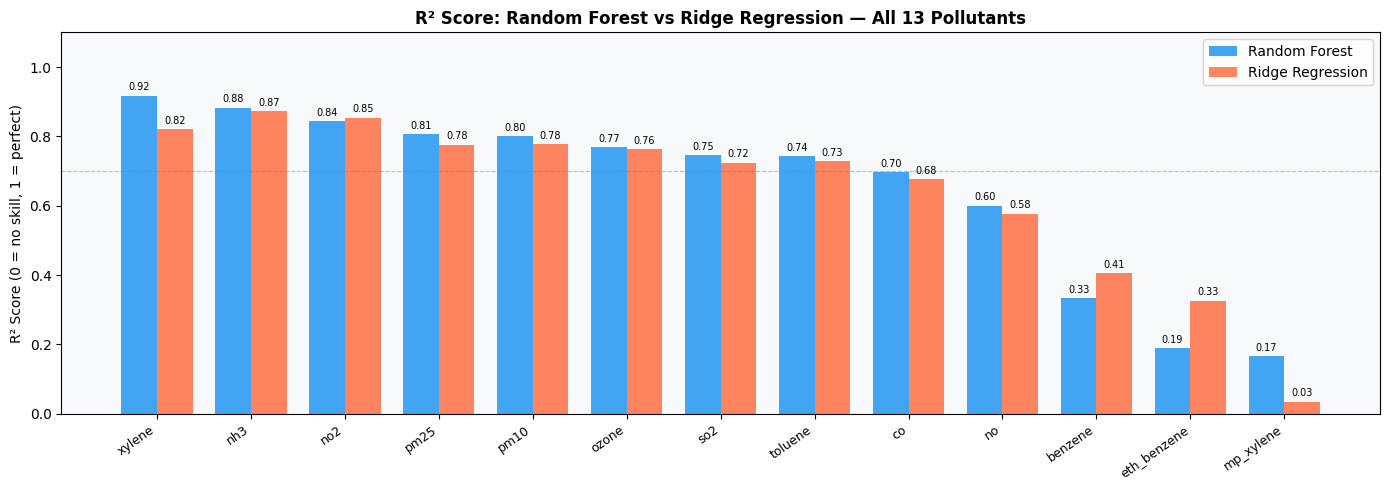

In [ ]:
# Visual 1: R² comparison RF vs Ridge
rf_r2    = results_df[results_df['model_name']=='RandomForest'].set_index('pollutant')['r2']
ridge_r2 = results_df[results_df['model_name']=='Ridge'].set_index('pollutant')['r2']
polls_sorted = rf_r2.sort_values(ascending=False).index
x = np.arange(len(polls_sorted))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - w/2, rf_r2[polls_sorted],    w, label='Random Forest',    color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + w/2, ridge_r2[polls_sorted], w, label='Ridge Regression', color='#FF7043', alpha=0.85)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(polls_sorted, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('R² Score (0 = no skill, 1 = perfect)', fontsize=10)
ax.set_title('R² Score: Random Forest vs Ridge Regression — All 13 Pollutants', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylim(0, 1.1)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

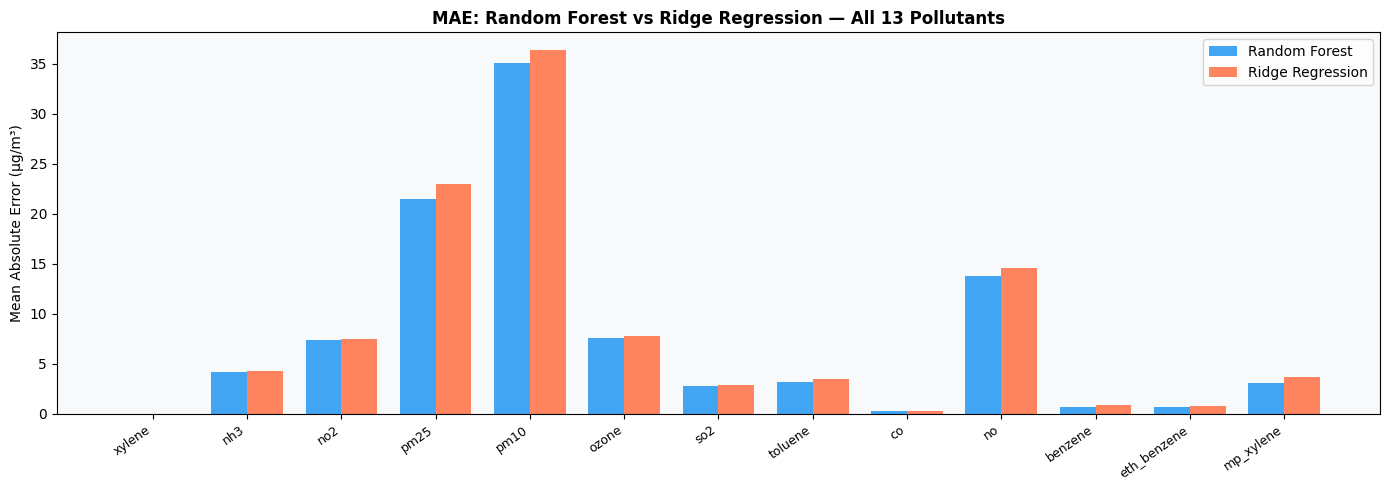

In [ ]:
# Visual 2: MAE comparison
rf_mae    = results_df[results_df['model_name']=='RandomForest'].set_index('pollutant')['mae']
ridge_mae = results_df[results_df['model_name']=='Ridge'].set_index('pollutant')['mae']

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, rf_mae[polls_sorted],    w, label='Random Forest',    color='#2196F3', alpha=0.85)
ax.bar(x + w/2, ridge_mae[polls_sorted], w, label='Ridge Regression', color='#FF7043', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(polls_sorted, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean Absolute Error (µg/m³)', fontsize=10)
ax.set_title('MAE: Random Forest vs Ridge Regression — All 13 Pollutants', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

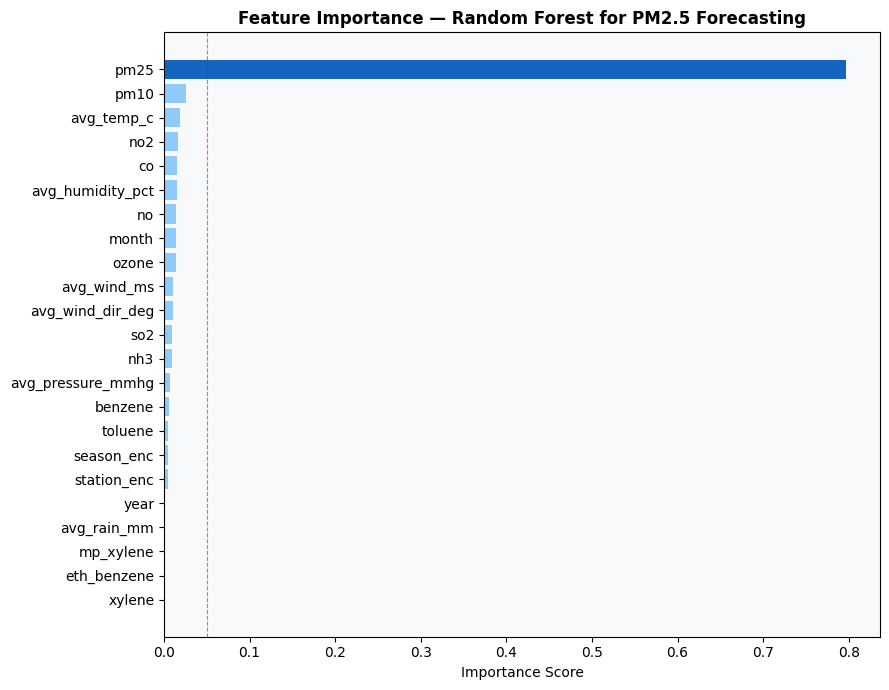


Top 5 most important features:
   feature  importance
      pm25    0.796687
      pm10    0.025737
avg_temp_c    0.018895
       no2    0.015882
        co    0.015268


In [ ]:
# Visual 3: Feature importance (RF on PM2.5)
subset_pm25 = ml_data[FEATURE_COLS + ['next_pm25']].dropna(subset=['next_pm25','pm25','no2','pm10'])
X_pm = subset_pm25[FEATURE_COLS].fillna(0).values
y_pm = subset_pm25['next_pm25'].values
X_tr, X_te, y_tr, y_te = train_test_split(X_pm, y_pm, test_size=0.2, random_state=42)

rf_fi = Pipeline([('sc', StandardScaler()),
                  ('m', RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1))])
rf_fi.fit(X_tr, y_tr)

fi_df = pd.DataFrame({'feature': FEATURE_COLS,
                      'importance': rf_fi.named_steps['m'].feature_importances_}
                    ).sort_values('importance')

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#1565C0' if v > 0.05 else '#90CAF9' for v in fi_df['importance']]
ax.barh(fi_df['feature'], fi_df['importance'], color=colors)
ax.set_xlabel('Importance Score', fontsize=10)
ax.set_title('Feature Importance — Random Forest for PM2.5 Forecasting', fontsize=12, fontweight='bold')
ax.axvline(0.05, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(fi_df.tail(5)[['feature','importance']].iloc[::-1].to_string(index=False))

## Step 6 — Per-Station R² Breakdown

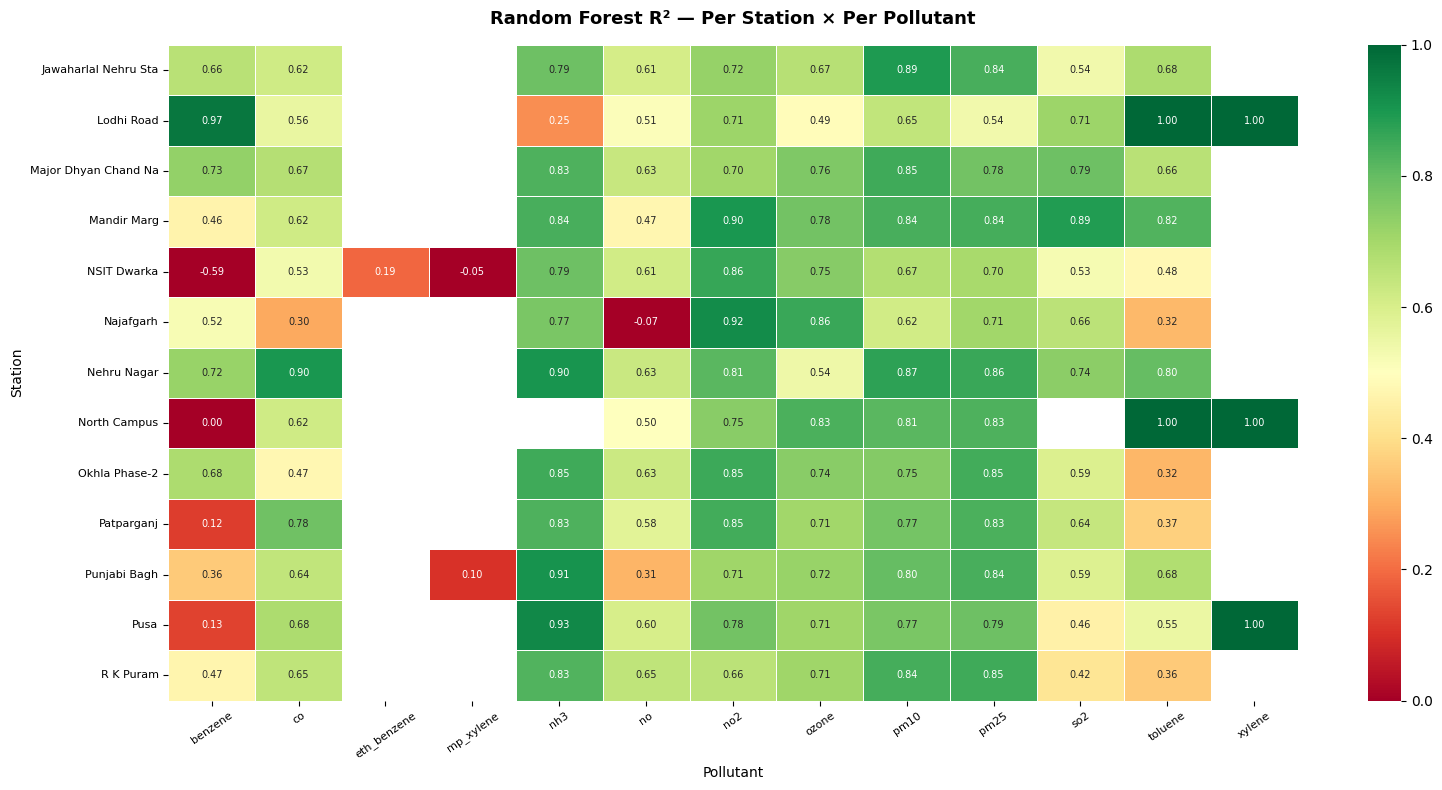

Green = high R² (easy to predict)  |  Red = low R² (harder to predict)


In [ ]:
# Visual 4: Heatmap — per-station R² for RF across all pollutants
station_names = dict(zip(stations['station_id'], stations['station_name']))
rf_station = station_df[station_df['model']=='RandomForest'].copy()
rf_station['station_short'] = rf_station['station_id'].map(
    lambda s: station_names.get(s, s).split(',')[0].strip()[:20]
)

pivot = rf_station.pivot_table(index='station_short', columns='pollutant', values='r2')

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 7})
ax.set_title('Random Forest R² — Per Station × Per Pollutant', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Pollutant', fontsize=10)
ax.set_ylabel('Station', fontsize=10)
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()
print('Green = high R² (easy to predict)  |  Red = low R² (harder to predict)')

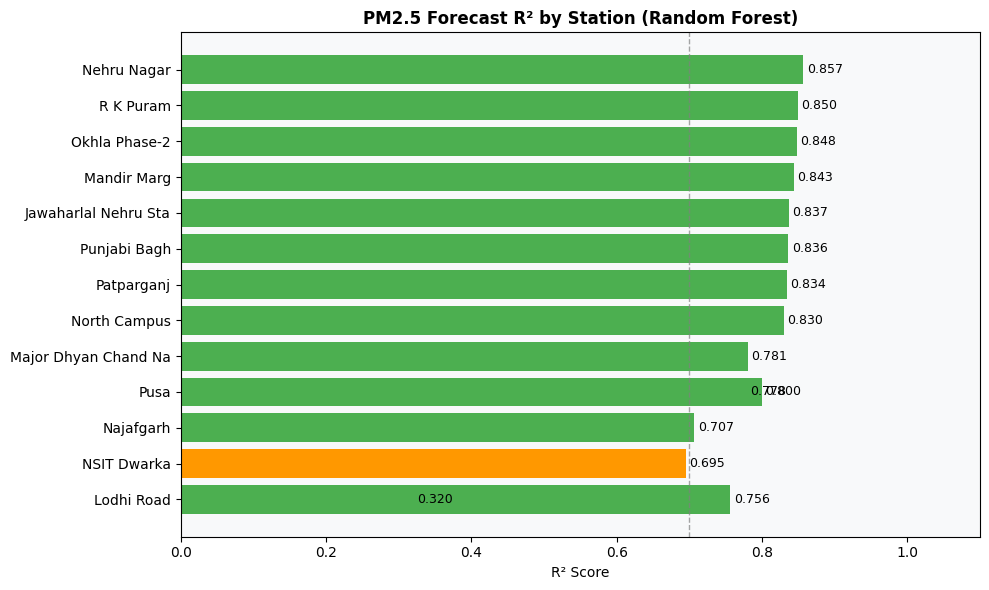

In [ ]:
# Visual 5: Per-station R² for PM2.5
pm25_station = rf_station[rf_station['pollutant']=='pm25'].sort_values('r2', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4CAF50' if v >= 0.7 else '#FF9800' if v >= 0.5 else '#F44336' for v in pm25_station['r2']]
bars = ax.barh(pm25_station['station_short'], pm25_station['r2'], color=colors)
for bar, val in zip(bars, pm25_station['r2']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('R² Score', fontsize=10)
ax.set_title('PM2.5 Forecast R² by Station (Random Forest)', fontsize=12, fontweight='bold')
ax.axvline(0.7, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlim(0, 1.1)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

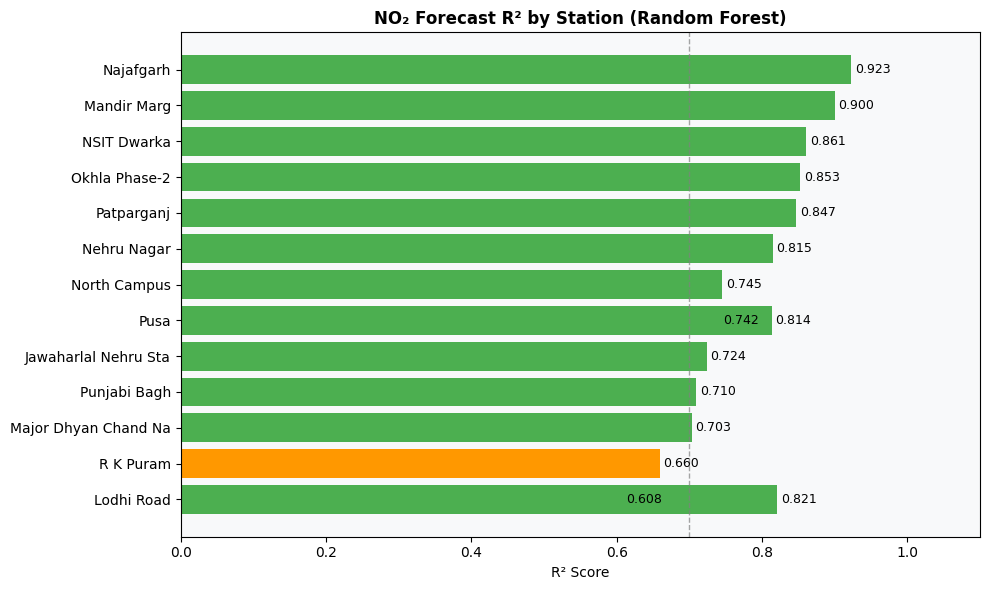

In [ ]:
# Visual 6: Per-station R² for NO2
no2_station = rf_station[rf_station['pollutant']=='no2'].sort_values('r2', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4CAF50' if v >= 0.7 else '#FF9800' if v >= 0.5 else '#F44336' for v in no2_station['r2']]
bars = ax.barh(no2_station['station_short'], no2_station['r2'], color=colors)
for bar, val in zip(bars, no2_station['r2']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('R² Score', fontsize=10)
ax.set_title('NO₂ Forecast R² by Station (Random Forest)', fontsize=12, fontweight='bold')
ax.axvline(0.7, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlim(0, 1.1)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

## Step 7 — Predicted vs Actual: All 13 Pollutants

Each plot shows the **daily average** actual vs predicted concentration across all stations, using the Random Forest model. MAE and R² are shown in each title.

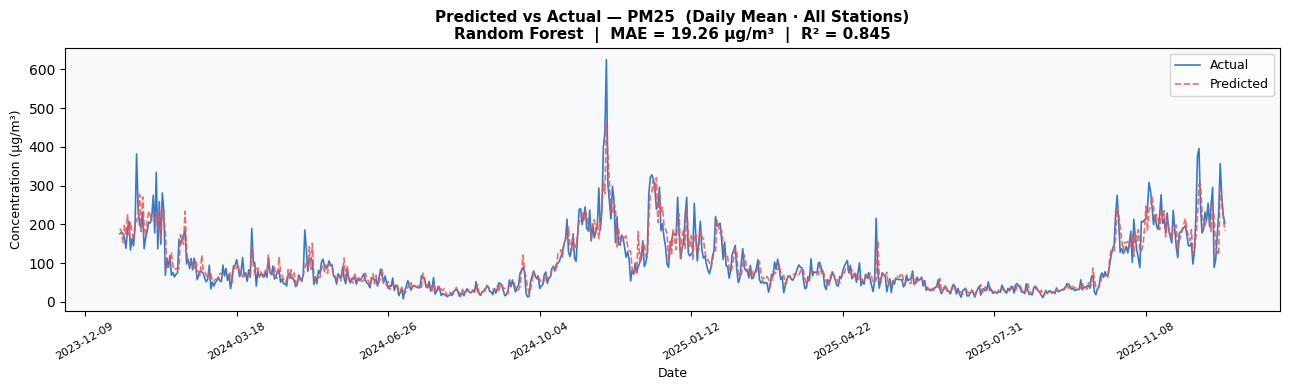

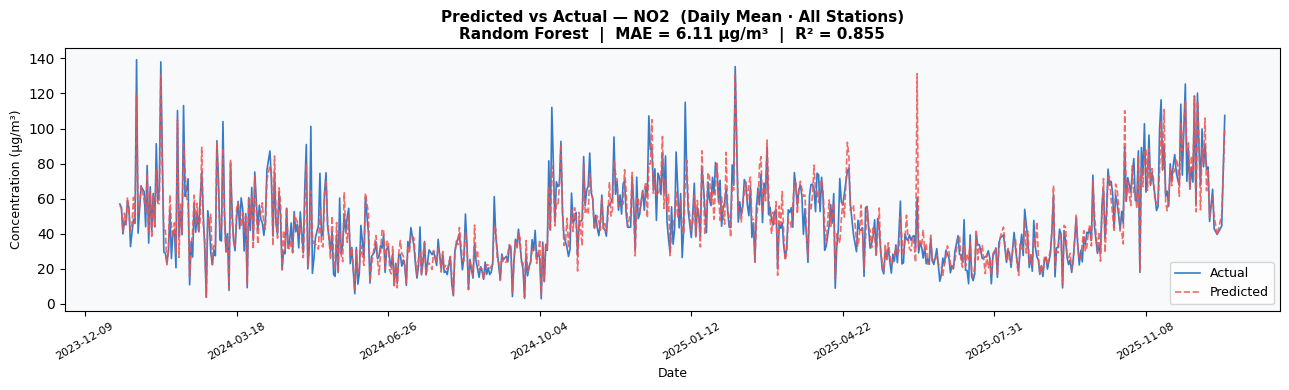

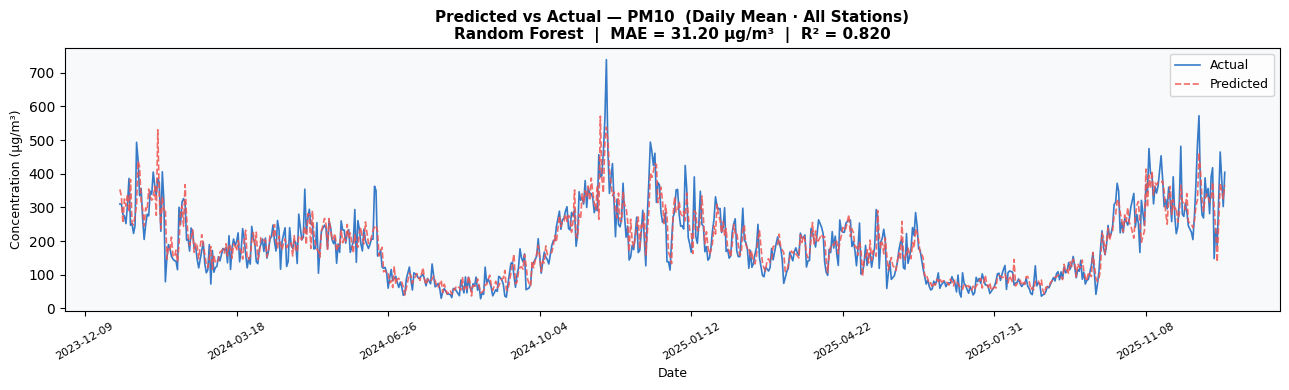

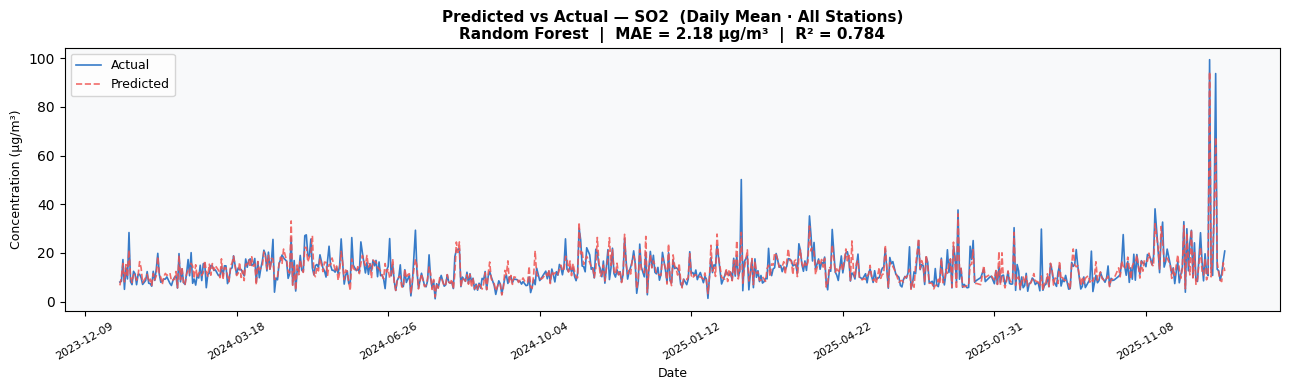

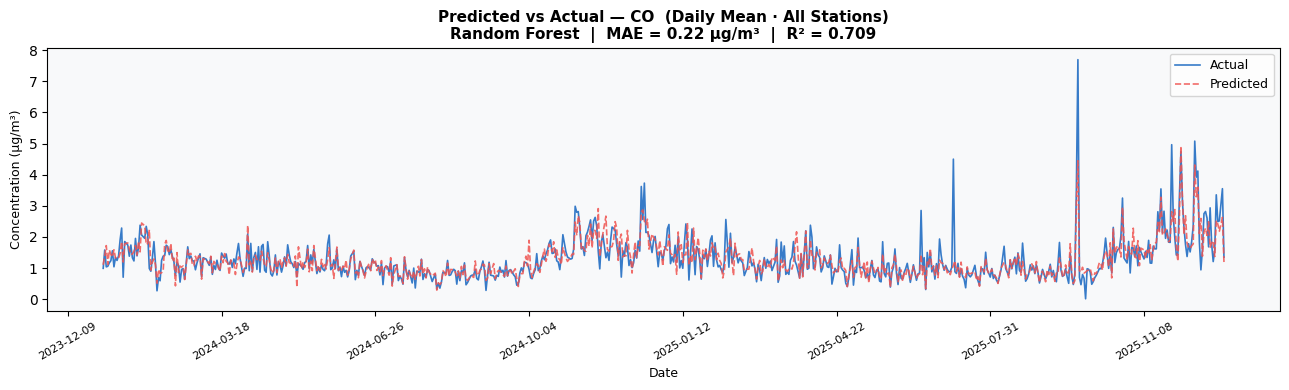

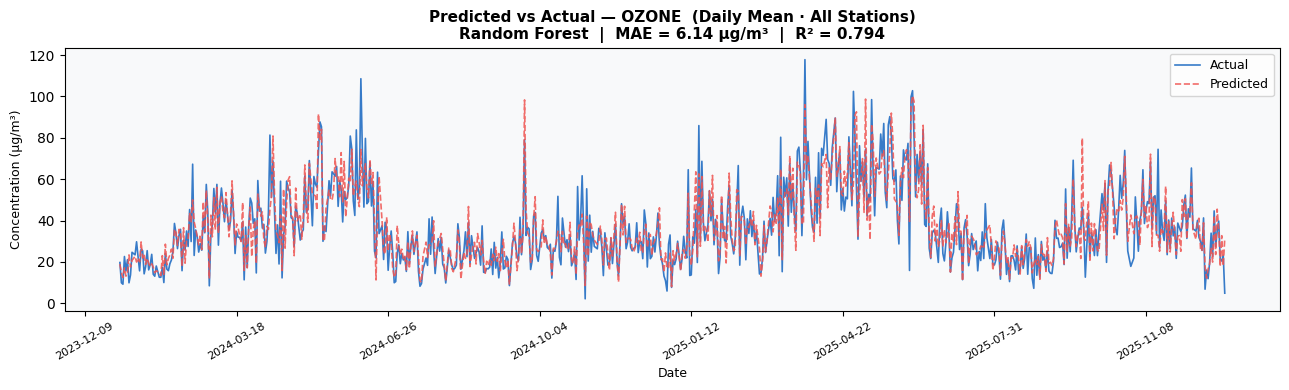

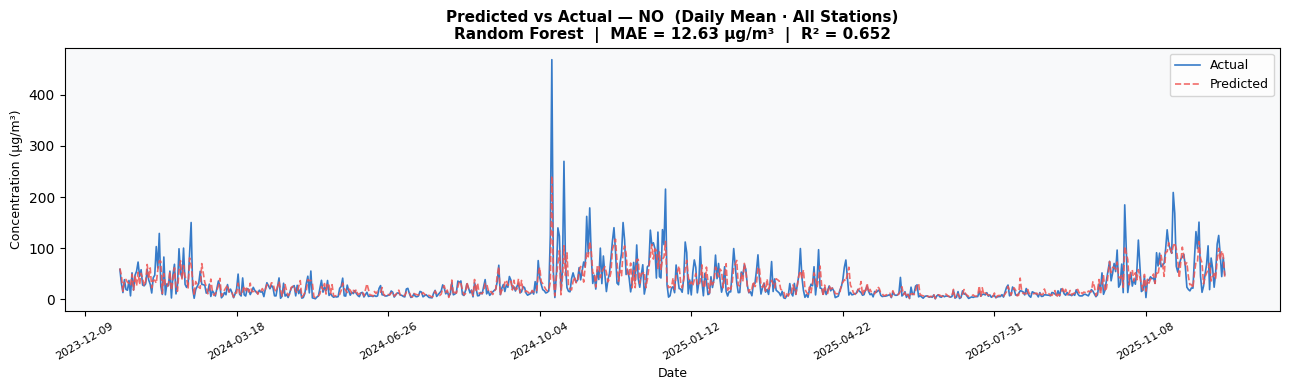

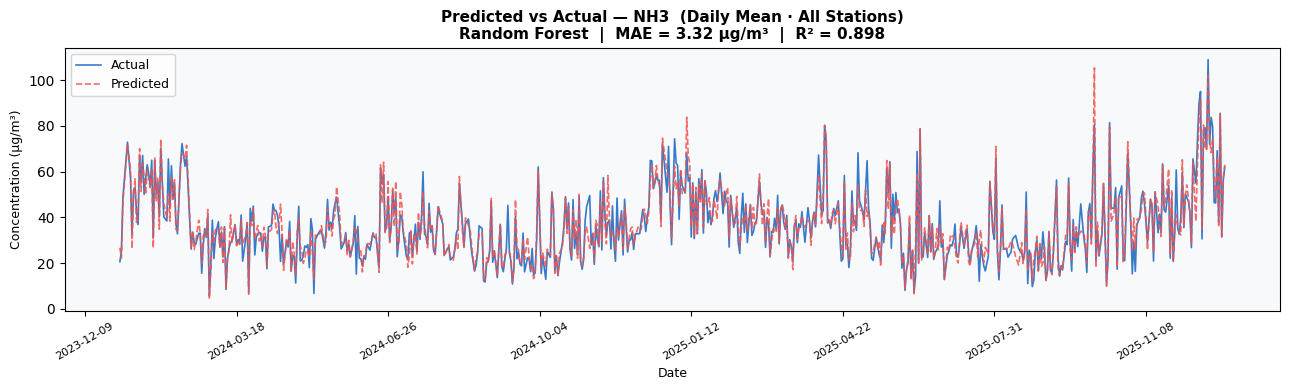

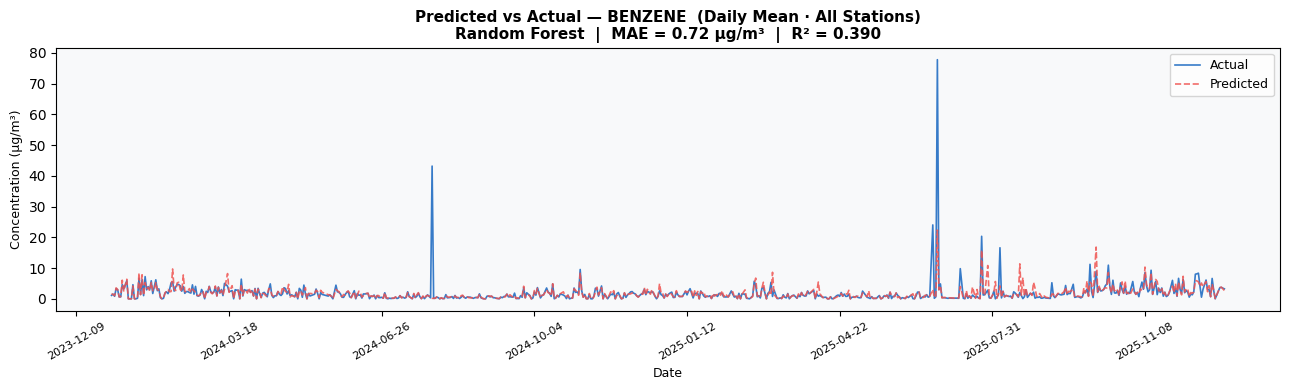

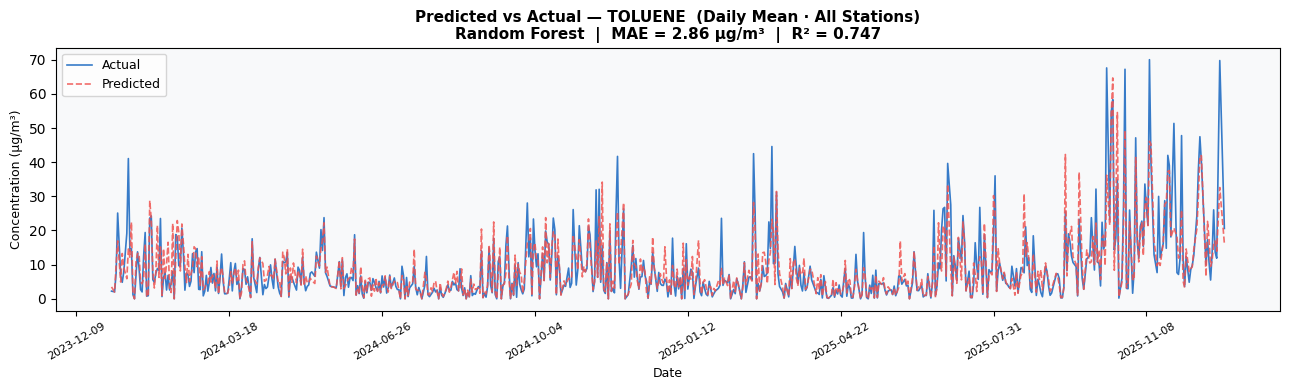

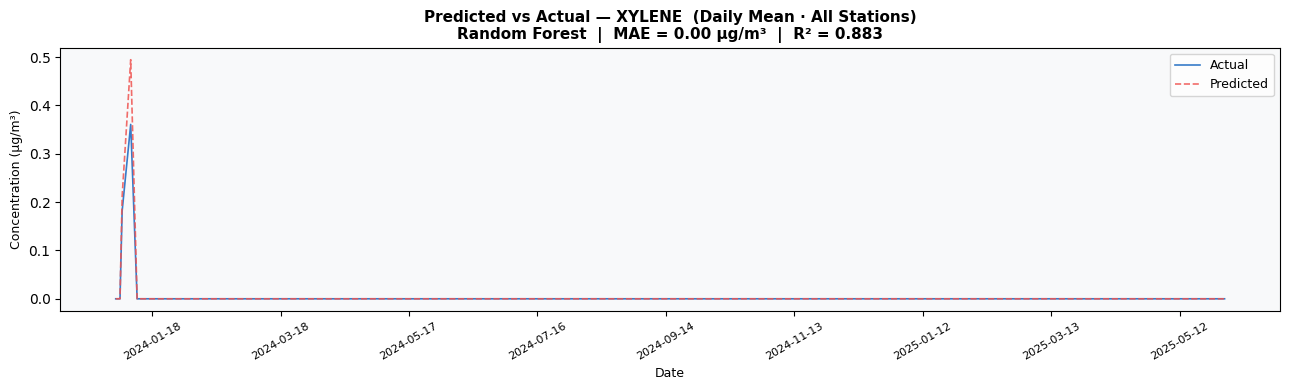

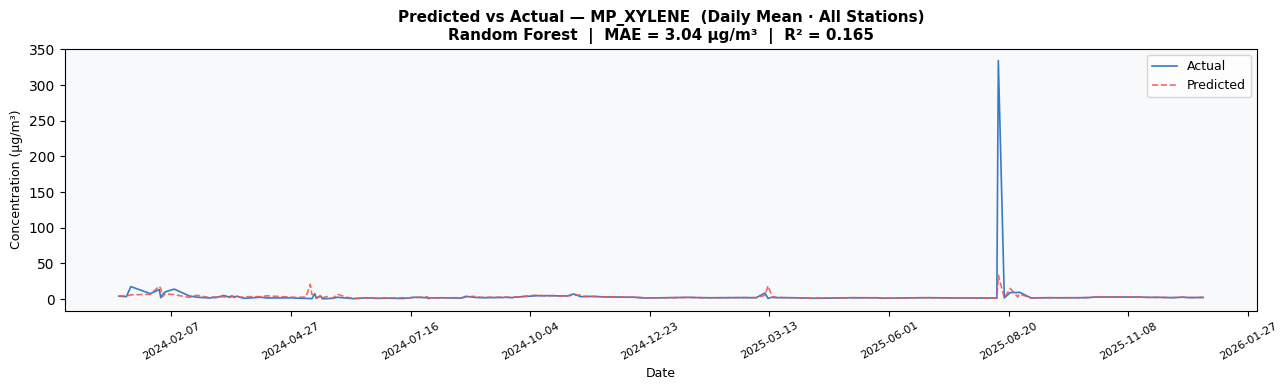

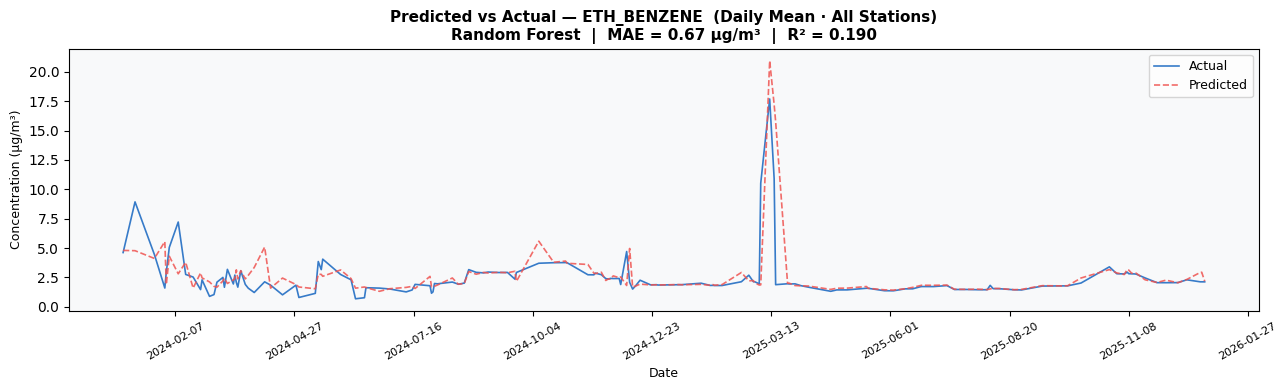

In [ ]:
available_polls = [p for p in ALL_POLLUTANTS if p in pred_actual]

for pollutant in available_polls:
    pa = pred_actual[pollutant].copy()
    pa['date'] = pd.to_datetime(pa['date'])
    pa = pa.sort_values('date')

    mae_val = mean_absolute_error(pa['actual'], pa['predicted'])
    r2_val  = r2_score(pa['actual'], pa['predicted'])

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(pa['date'], pa['actual'],    label='Actual',    color='#1565C0', linewidth=1.2, alpha=0.85)
    ax.plot(pa['date'], pa['predicted'], label='Predicted', color='#EF5350', linewidth=1.2, linestyle='--', alpha=0.85)
    ax.set_title(
        f'Predicted vs Actual — {pollutant.upper()}  (Daily Mean · All Stations)\n'
        f'Random Forest  |  MAE = {mae_val:.2f} µg/m³  |  R² = {r2_val:.3f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Concentration (µg/m³)', fontsize=9)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.show()

## Step 8 — Analytical SQL Queries

In [ ]:
# Q1: Top PM2.5 stations per season
q1 = pd.read_sql("""
    SELECT   w.season, s.station_name,
             ROUND(AVG(f.avg_value), 2) AS avg_pm25
    FROM     fact_daily_pollutants f
    JOIN     dim_pollutant  p ON p.pollutant_id = f.pollutant_id
    JOIN     dim_station    s ON s.station_id   = f.station_id
    JOIN     fact_daily_weather w ON w.station_id = f.station_id AND w.date = f.date
    WHERE    p.pollutant_code = 'pm25'
    GROUP BY w.season, f.station_id
    ORDER BY w.season, avg_pm25 DESC
""", conn)
print('Top 3 PM2.5 stations per season:')
print(q1.groupby('season').head(3).to_string(index=False))

Top 3 PM2.5 stations per season:
      season               station_name  avg_pm25
     Monsoon    R K Puram, Delhi - DPCC     46.88
     Monsoon Punjabi Bagh, Delhi - DPCC     43.34
     Monsoon  NSIT Dwarka, Delhi - CPCB     42.22
Post-Monsoon Punjabi Bagh, Delhi - DPCC    197.17
Post-Monsoon  Nehru Nagar, Delhi - DPCC    195.63
Post-Monsoon    R K Puram, Delhi - DPCC    186.07
      Summer  NSIT Dwarka, Delhi - CPCB     91.26
      Summer Punjabi Bagh, Delhi - DPCC     81.13
      Summer   Lodhi Road, Delhi - IITM     80.15
      Winter  Nehru Nagar, Delhi - DPCC    205.73
      Winter Punjabi Bagh, Delhi - DPCC    187.75
      Winter    R K Puram, Delhi - DPCC    186.98


In [ ]:
# Q2: Monthly pollution trend
q2 = pd.read_sql("""
    SELECT month,
           ROUND(AVG(pm25), 2)       AS avg_pm25,
           ROUND(AVG(no2),  2)       AS avg_no2,
           ROUND(AVG(avg_temp_c), 1) AS avg_temp_c
    FROM   fact_ml_features
    GROUP  BY month ORDER BY month
""", conn)
print('Monthly pollution averages:')
print(q2.to_string(index=False))

Monthly pollution averages:
 month  avg_pm25  avg_no2  avg_temp_c
     1    183.43    57.81        17.8
     2     97.01    55.61        20.6
     3     68.59    48.34        23.9
     4     67.93    50.70        28.6
     5     73.66    38.89        30.3
     6     48.99    30.78        31.0
     7     32.77    25.76        29.6
     8     27.73    25.29        29.0
     9     35.66    28.45        29.0
    10    102.84    48.08        27.6
    11    216.42    65.26        24.1
    12    181.01    64.81        20.3


In [ ]:
# Q3: Model leaderboard
print('Full model leaderboard:')
print(pd.read_sql(
    'SELECT pollutant, model_name, mae, rmse, r2 FROM model_metrics ORDER BY pollutant, r2 DESC',
    conn).to_string(index=False))
conn.close()

Full model leaderboard:
  pollutant   model_name    mae   rmse     r2
    benzene        Ridge  0.831  3.167 0.4050
    benzene RandomForest  0.686  3.354 0.3327
         co RandomForest  0.269  0.432 0.6965
         co        Ridge  0.279  0.446 0.6757
eth_benzene        Ridge  0.770  1.576 0.3259
eth_benzene RandomForest  0.667  1.728 0.1895
  mp_xylene RandomForest  3.042 24.265 0.1655
  mp_xylene        Ridge  3.717 26.104 0.0342
        nh3 RandomForest  4.134  6.669 0.8823
        nh3        Ridge  4.240  6.934 0.8727
         no RandomForest 13.779 25.169 0.6001
         no        Ridge 14.568 25.874 0.5774
        no2        Ridge  7.455 11.120 0.8537
        no2 RandomForest  7.375 11.492 0.8438
      ozone RandomForest  7.550 11.363 0.7689
      ozone        Ridge  7.754 11.512 0.7628
       pm10 RandomForest 35.089 49.417 0.8003
       pm10        Ridge 36.333 52.178 0.7773
       pm25 RandomForest 21.507 35.013 0.8066
       pm25        Ridge 23.022 37.747 0.7752
        so

---
## Summary

| | |
|---|---|
| **Database** | SQLite · star schema · 6 tables · normalised Silver + denormalised Gold |
| **Models** | Random Forest (150 trees) · Ridge Regression |
| **Pollutants forecasted** | All 13 |
| **Best results** | NH₃ R²=0.88 · Xylene R²=0.92 · NO₂ R²=0.84 · PM2.5 R²=0.81 |
| **Weaker pollutants** | mp-Xylene, Ethylbenzene (sparse data — fewer measuring stations) |
| **Top predictor feature** | Same-day PM2.5 level (importance = 0.80) |
| **Key insight** | Pollution persists day-to-day — today's level is the strongest signal for tomorrow |
